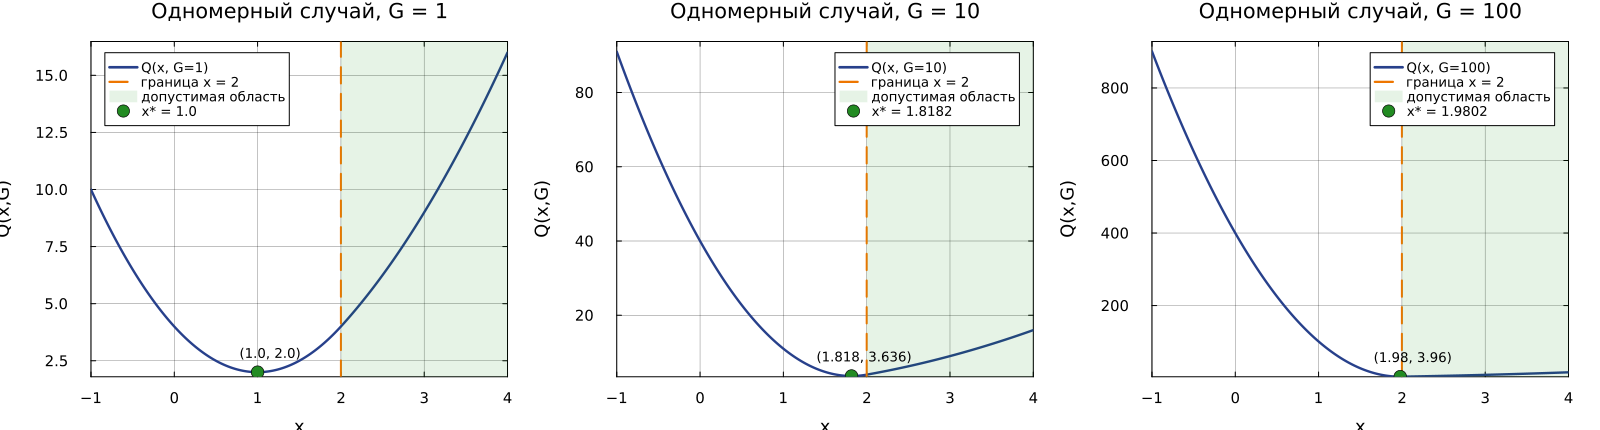

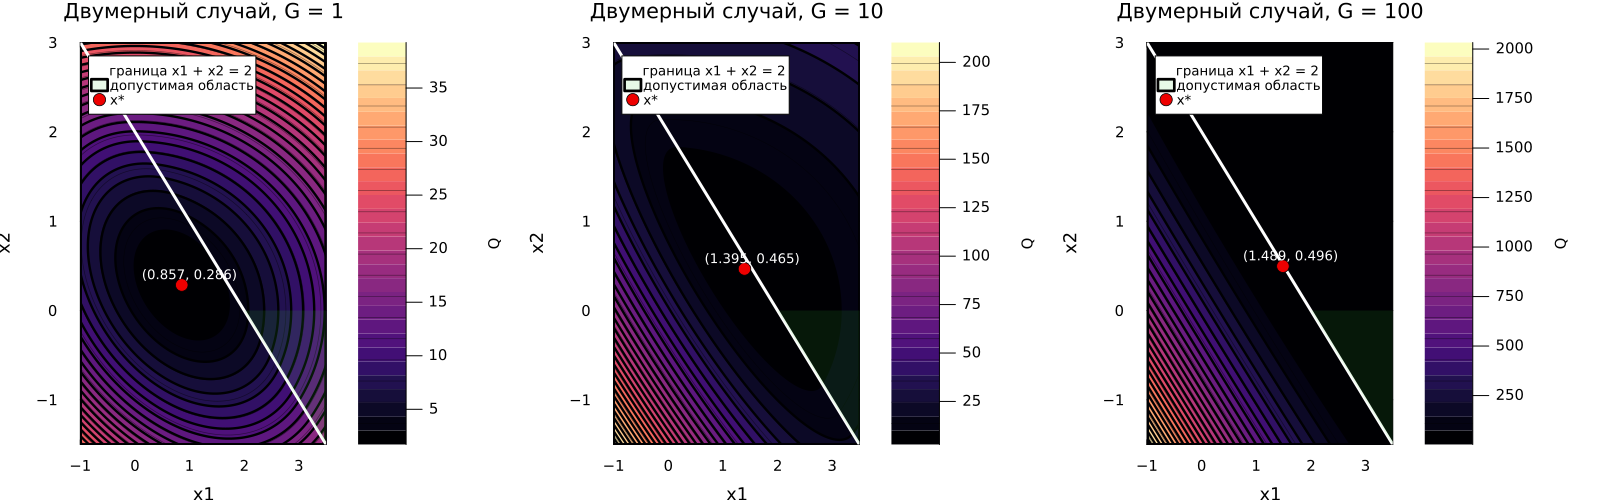

Одномерный случай
G = 1, x* = 1.0, Q* = 2.0
G = 10, x* = 1.81818, Q* = 3.63636
G = 100, x* = 1.9802, Q* = 3.9604

Двумерный случай
G = 1, x* = (0.85714, 0.28571), Q* = 1.71429
G = 10, x* = (1.39535, 0.46512), Q* = 2.7907
G = 100, x* = (1.48883, 0.49628), Q* = 2.97767


In [1]:
using Plots

gr()

default(
    fontfamily="sans-serif",
    linewidth=2.4,
    legendfontsize=9,
    guidefontsize=12,
    tickfontsize=10,
    titlefontsize=14,
    size=(1600, 900),
    gridalpha=0.25,
    framestyle=:box
)

Γs = [1.0, 10.0, 100.0]
β = 3.0

f1(x) = x^2
g1(x) = 2.0 - x
G1(x) = ((g1(x) + abs(g1(x))) / 2.0)^2
Q1(x, Γ) = f1(x) + Γ * G1(x)

xstar1(Γ) = 2.0 * Γ / (1.0 + Γ)
qstar1(Γ) = Q1(xstar1(Γ), Γ)

f2(x1, x2) = x1^2 + β * x2^2
g2(x1, x2) = 2.0 - x1 - x2
G2(x1, x2) = ((g2(x1, x2) + abs(g2(x1, x2))) / 2.0)^2
Q2(x1, x2, Γ) = f2(x1, x2) + Γ * G2(x1, x2)

x1star2(Γ) = 2.0 * β * Γ / (β * Γ + Γ + β)
x2star2(Γ) = 2.0 * Γ / (β * Γ + Γ + β)
qstar2(Γ) = Q2(x1star2(Γ), x2star2(Γ), Γ)

xs = range(-1.0, 4.0, length=1600)

p1 = plot(layout=(1, 3), size=(1600, 430), margin=6Plots.mm)

for (i, Γ) in enumerate(Γs)
    ys = [Q1(x, Γ) for x in xs]
    xm = xstar1(Γ)
    ym = qstar1(Γ)
    ymin = minimum(ys)
    ymax = maximum(ys)

    plot!(
        p1[i], xs, ys,
        color=:royalblue4,
        label="Q(x, G=$(Int(Γ)))",
        xlabel="x",
        ylabel="Q(x,G)",
        title="Одномерный случай, G = $(Int(Γ))",
        xlims=(-1, 4),
        ylims=(ymin - 0.2, ymax * 1.03)
    )

    vline!(
        p1[i], [2.0],
        color=:darkorange2,
        linestyle=:dash,
        linewidth=2.0,
        label="граница x = 2"
    )

    plot!(
        p1[i], [2.0, 4.0], [ymin - 1.0, ymin - 1.0],
        fillrange=[ymax * 1.1, ymax * 1.1],
        fillalpha=0.10,
        color=:green4,
        linealpha=0.0,
        label="допустимая область"
    )

    scatter!(
        p1[i], [xm], [ym],
        color=:forestgreen,
        markerstrokecolor=:black,
        markerstrokewidth=0.8,
        markersize=7,
        label="x* = $(round(xm, digits=4))"
    )

    annotate!(
        p1[i], xm + 0.15, ym + 0.06 * (ymax - ymin),
        text("($(round(xm, digits=3)), $(round(ym, digits=3)))", 9, :black)
    )
end

display(p1)

x1s = range(-1.0, 3.5, length=500)
x2s = range(-1.5, 3.0, length=500)

p2 = plot(layout=(1, 3), size=(1600, 500), margin=6Plots.mm)

for (i, Γ) in enumerate(Γs)
    Z = [Q2(x1, x2, Γ) for x2 in x2s, x1 in x1s]
    xm1 = x1star2(Γ)
    xm2 = x2star2(Γ)

    contourf!(
        p2[i], x1s, x2s, Z,
        levels=28,
        c=:magma,
        xlabel="x1",
        ylabel="x2",
        title="Двумерный случай, G = $(Int(Γ))",
        xlims=(-1, 3.5),
        ylims=(-1.5, 3.0),
        colorbar_title="Q"
    )

    contour!(
        p2[i], x1s, x2s, Z,
        levels=18,
        color=:black,
        linewidth=0.7,
        alpha=0.45,
        label=""
    )

    plot!(
        p2[i], x1s, [2.0 - x1 for x1 in x1s],
        color=:white,
        linewidth=3,
        label="граница x1 + x2 = 2"
    )

    px = [2.0, 3.5, 3.5]
    py = [0.0, -1.5, 0.0]
    plot!(
        p2[i], px, py,
        seriestype=:shape,
        fillcolor=:limegreen,
        fillalpha=0.12,
        linealpha=0.0,
        label="допустимая область"
    )

    scatter!(
        p2[i], [xm1], [xm2],
        color=:red2,
        markerstrokecolor=:black,
        markerstrokewidth=0.8,
        markersize=7,
        label="x*"
    )

    annotate!(
        p2[i], xm1 + 0.14, xm2 + 0.12,
        text("($(round(xm1, digits=3)), $(round(xm2, digits=3)))", 9, :white)
    )
end

display(p2)

println("Одномерный случай")
for Γ in Γs
    println("G = $(Int(Γ)), x* = $(round(xstar1(Γ), digits=5)), Q* = $(round(qstar1(Γ), digits=5))")
end

println()
println("Двумерный случай")
for Γ in Γs
    println("G = $(Int(Γ)), x* = ($(round(x1star2(Γ), digits=5)), $(round(x2star2(Γ), digits=5))), Q* = $(round(qstar2(Γ), digits=5))")
end